<a href="https://colab.research.google.com/github/jellybbie/study/blob/project1/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd

# Read the Excel file into a DataFrame
df = pd.read_excel('/content/rawdata-gray02.xlsx')

# Display the first 5 rows of the DataFrame
display(df.head())

,Treatment,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6
0,Spray TAU-3,4.0,4.0,5.0,3.0,4.0,5.0
1,Spray BTH,4.0,4.0,4.0,3.0,5.0,4.0
2,Spray MgSO4,3.0,3.0,4.0,1.0,4.0,5.0
3,Drench TAU-3,4.0,5.0,5.0,1.0,4.0,5.0
4,Drench BTH,3.0,5.0,5.0,1.0,5.0,5.0


## 데이터 기술 통계량

`describe()` 함수를 사용하여 데이터프레임의 각 수치형 컬럼에 대한 기술 통계량을 확인합니다.

In [3]:
# Display descriptive statistics of the DataFrame
display(df.describe())

,repeat1,repeat2,repeat3,repeat4,repeat5,repeat6
count,6.000000,6.000000,6.000000,6.000000,6.000000,6.00000
mean,3.666667,4.666667,4.333333,3.500000,4.333333,3.50000
std,0.816497,0.816497,1.032796,1.378405,0.816497,0.83666
min,3.000000,3.000000,3.000000,2.000000,3.000000,3.00000
25%,3.000000,5.000000,3.500000,2.250000,4.000000,3.00000
50%,3.500000,5.000000,5.000000,3.500000,4.500000,3.00000
75%,4.000000,5.000000,5.000000,4.750000,5.000000,3.75000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000


## Treatment별 데이터 시각화

각 `Treatment`에 대한 `repeat` 값들의 평균을 계산하고, 이를 막대 그래프로 시각화하여 비교합니다.

/tmp/ipykernel_989/4017404491.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Treatment', y='Average_Value', data=treatment_avg, palette='viridis')


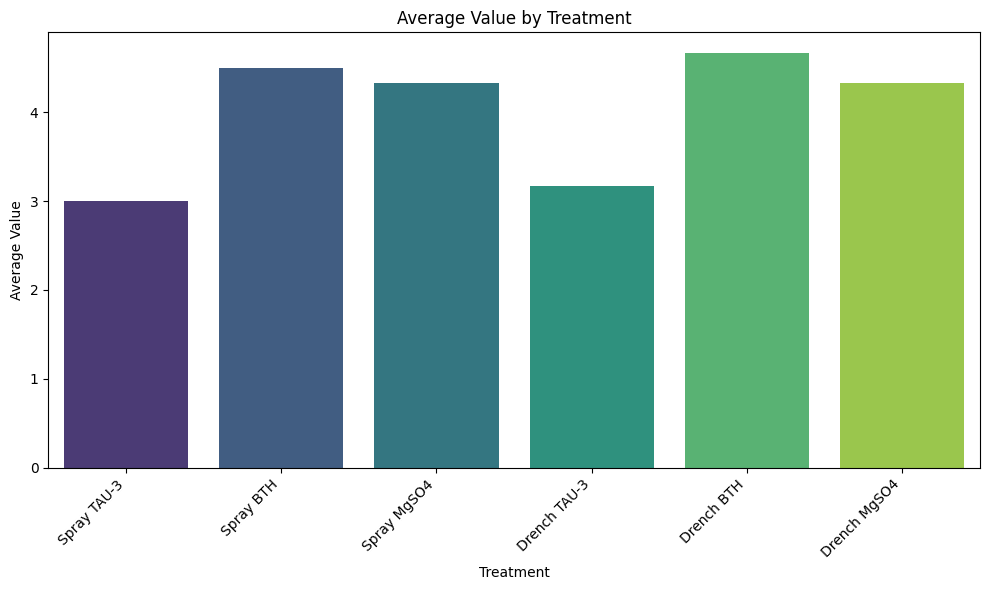

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the mean of the repeat columns for each Treatment
df_mean = df.groupby('Treatment').mean().reset_index()

# Reshape the DataFrame to long format for easier plotting (optional, but good for Seaborn)
df_mean_melted = df_mean.melt(id_vars=['Treatment'], var_name='Repeat', value_name='Value')

# Group by Treatment and calculate the mean across all repeat columns for plotting
treatment_avg = df.set_index('Treatment').filter(like='repeat').mean(axis=1).reset_index(name='Average_Value')

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Treatment', y='Average_Value', data=treatment_avg, palette='viridis')
plt.title('Average Value by Treatment')
plt.xlabel('Treatment')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 오차 막대 및 통계적 유의성 분석이 포함된 Treatment별 막대 그래프

각 Treatment 그룹의 평균 값에 대한 오차 막대(표준 오차)를 추가하고, 통계 분석(ANOVA 및 Tukey's HSD)을 통해 유의미하게 다른 그룹을 알파벳으로 표시하여 시각화합니다.

ANOVA F-statistic: 0.39
ANOVA p-value: 0.811
No significant overall difference between treatment groups (p >= 0.05).


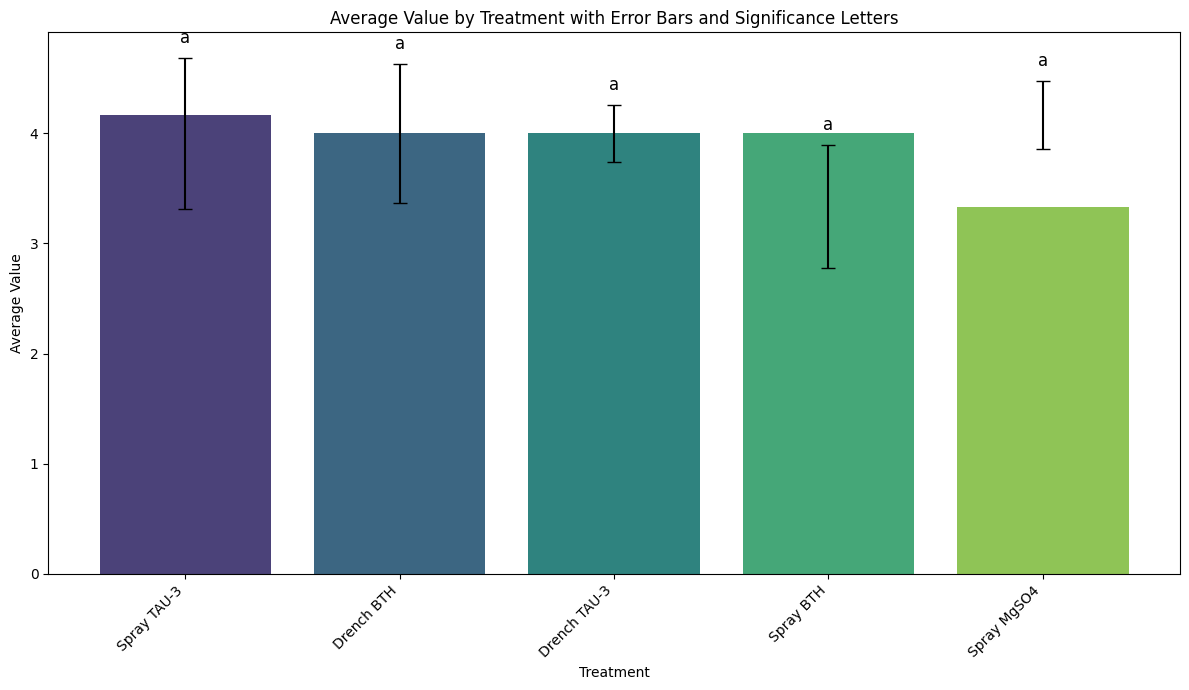

In [11]:
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import numpy as np

# Exclude 'Drench MgSO4' treatment due to all NaN values
df_filtered = df[df['Treatment'] != 'Drench MgSO4'].copy()

# 1. Melt the DataFrame to long format for statistical analysis
df_long = df_filtered.melt(id_vars=['Treatment'], var_name='Repeat', value_name='Value').dropna()

# 2. Perform ANOVA to check for overall significance
# Get unique treatments
treatments = df_long['Treatment'].unique()

# Create a list of value arrays for each treatment
data_for_anova = [df_long['Value'][df_long['Treatment'] == t].values for t in treatments]

f_statistic, p_value = stats.f_oneway(*data_for_anova)

print(f"ANOVA F-statistic: {f_statistic:.2f}")
print(f"ANOVA p-value: {p_value:.3f}")

if p_value < 0.05:
    print("Overall significant difference between treatment groups (p < 0.05).")
    # 3. Perform Tukey's HSD post-hoc test
    tukey_result = pairwise_tukeyhsd(endog=df_long['Value'], groups=df_long['Treatment'], alpha=0.05)
    print("\nTukey's HSD Post-hoc Test Results:")
    print(tukey_result)

    # Determine significance letters using a more robust approach
    letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

    # Create a DataFrame for Tukey's results for easier processing
    tukey_df = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])

    # Initialize final_letters dictionary
    final_letters = {}
    letter_idx = 0

    # Iterate through treatments to assign letters based on non-significant groups
    for t in treatments:
        if t not in final_letters:
            group_of_t = [t]
            for other_t in treatments:
                if t != other_t:
                    # Check for non-significant difference between t and other_t using tukey_df
                    pair_row = tukey_df[
                        ((tukey_df['group1'] == t) & (tukey_df['group2'] == other_t)) |
                        ((tukey_df['group1'] == other_t) & (tukey_df['group2'] == t))
                    ]
                    # If the pair is not rejected (i.e., not significantly different)
                    if not pair_row.empty and not pair_row['reject'].iloc[0]:
                        group_of_t.append(other_t)

            # Assign the same letter to all treatments in this non-significant group
            assigned_this_round = False
            for member in group_of_t:
                if member not in final_letters:
                    final_letters[member] = letters[letter_idx]
                    assigned_this_round = True
            if assigned_this_round:
                letter_idx += 1

    print("\nLetter assignments for significant groups:", final_letters)
else:
    print("No significant overall difference between treatment groups (p >= 0.05).")
    final_letters = {t: 'a' for t in treatments} # Assign 'a' to all if no overall significance


# 4. Calculate summary statistics for plotting (mean and SEM)
summary_df = df_long.groupby('Treatment')['Value'].agg(['mean', 'sem']).reset_index()
summary_df.rename(columns={'mean': 'Average_Value', 'sem': 'SEM'}, inplace=True)

# Add letter assignments to the summary_df
summary_df['Letters'] = summary_df['Treatment'].map(final_letters)

# Sort by Average_Value for better visualization if desired, or by Treatment for consistency
summary_df = summary_df.sort_values(by='Average_Value', ascending=False) # Sort by average value

# 5. Create the bar plot with error bars and significance letters
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Treatment', y='Average_Value', data=summary_df, palette='viridis',
                 hue='Treatment', legend=False) # Removed yerr from here, added hue and legend=False

# Add error bars manually
for index, row in summary_df.iterrows():
    plt.errorbar(x=index, y=row['Average_Value'], yerr=row['SEM'], color='black', capsize=5, fmt='none')

    # Add significance letters
    # Position the letter above the error bar
    # Adjust letter position if needed based on the maximum value + error
    max_val = row['Average_Value'] + row['SEM'] + 0.1 # Small offset above the error bar
    plt.text(index, max_val, row['Letters'], color='black', ha="center", va='bottom', fontsize=12)

plt.title('Average Value by Treatment with Error Bars and Significance Letters')
plt.xlabel('Treatment')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# Construct the report content
report_content = """
# Statistical Analysis Report

## ANOVA Results
- F-statistic: {f_statistic:.2f}
- p-value: {p_value:.3f}

Overall significant difference between treatment groups (p < 0.05): {overall_significance}

## Tukey's HSD Post-hoc Test Results
{tukey_hsd_table}

## Significance Letter Assignments
{letter_assignments}
""".format(
    f_statistic=f_statistic,
    p_value=p_value,
    overall_significance="Yes" if p_value < 0.05 else "No",
    tukey_hsd_table=str(tukey_result),
    letter_assignments=str(final_letters)
)

# Save the report to a file
report_filename = '/content/statistical_report.txt'
with open(report_filename, 'w') as f:
    f.write(report_content)

print(f"Statistical report saved to {report_filename}")

Statistical report saved to /content/statistical_report.txt


In [8]:
# Read and display the content of the generated report file
with open(report_filename, 'r') as f:
    report_content_read = f.read()
print(report_content_read)


# Statistical Analysis Report

## ANOVA Results
- F-statistic: 4.62
- p-value: 0.003

Overall significant difference between treatment groups (p < 0.05): Yes

## Tukey's HSD Post-hoc Test Results
      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower   upper  reject
----------------------------------------------------------------
  Drench BTH Drench MgSO4  -0.3333 0.9804 -1.7791  1.1124  False
  Drench BTH Drench TAU-3     -1.5 0.0385 -2.9457 -0.0543   True
  Drench BTH    Spray BTH  -0.1667 0.9992 -1.6124  1.2791  False
  Drench BTH  Spray MgSO4  -0.3333 0.9804 -1.7791  1.1124  False
  Drench BTH  Spray TAU-3  -1.6667 0.0165 -3.1124 -0.2209   True
Drench MgSO4 Drench TAU-3  -1.1667 0.1703 -2.6124  0.2791  False
Drench MgSO4    Spray BTH   0.1667 0.9992 -1.2791  1.6124  False
Drench MgSO4  Spray MgSO4      0.0    1.0 -1.4457  1.4457  False
Drench MgSO4  Spray TAU-3  -1.3333 0.0841 -2.7791  0.1124  False
Drench TAU-3    Spray B